In [1]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("SIA Wevengers 분석 환경 준비 완료")

SIA Wevengers 분석 환경 준비 완료


In [ ]:

import pandas as pd
import pandas_gbq
from google.oauth2 import service_account

from google.oauth2 import service_account

# 1. 신분증(JSON 키) 경로 지정
KEY_PATH = 'google_key.json'

# 2. 인증 객체 생성
credentials = service_account.Credentials.from_service_account_file(KEY_PATH)

# 3. 프로젝트 ID 설정
project_id = 'coral-bucksaw-482803-p2'

# 4. 데이터 불러오기
query = "SELECT SQLDATE FROM `gdelt-bq.full.events` LIMIT 5"
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("인증 성공! 데이터를 가져왔습니다.")

Downloading: 100%|██████████|
인증 성공! 데이터를 가져왔습니다.


In [3]:
query = """
SELECT 
    SQLDATE,
    IsRootEvent,
    Actor1CountryCode,
    Actor2CountryCode,
    EventCode,
    EventBaseCode,
    EventRootCode,
    GoldsteinScale,
    QuadClass,
    NumMentions,
    NumArticles,
    NumSources,
    AvgTone,
    ActionGeo_Type,
    ActionGeo_Lat,
    ActionGeo_Long,
    ActionGeo_FullName,
    ActionGeo_CountryCode,
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE SQLDATE BETWEEN 20130401 AND 20261231
  AND (
    -- ✅ 핵심 수정: CountryCode 기반 필터링 (CHNGOV, CHNMIL 등 모두 포함)
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
"""

df = pandas_gbq.read_gbq(
    query,
    project_id=project_id,
    credentials=credentials,
    progress_bar_type='tqdm'   # 진행률 표시
)

print(f"총 {len(df):,}건 수집 완료")
display(df.head())

Downloading: 100%|██████████|
총 493,109건 수집 완료


,SQLDATE,IsRootEvent,Actor1CountryCode,Actor2CountryCode,EventCode,EventBaseCode,EventRootCode,GoldsteinScale,QuadClass,NumMentions,NumArticles,NumSources,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FullName,ActionGeo_CountryCode,SOURCEURL
0,20211218,0,CHN,TWN,180,180,18,-9.0,4,8,8,1,-0.871080,1,35.0000,105.0000,China,CH,https://nationalinterest.org/blog/reboot/us-sp...
1,20220918,0,CHN,TWN,045,045,04,5.0,1,1,1,1,-0.595480,2,42.1497,-74.9384,"New York, United States",US,https://www.heritage.org/defense/report/commer...
2,20220918,0,CHN,TWN,045,045,04,5.0,1,1,1,1,-0.595480,4,39.9289,116.3880,"Beijing, Beijing, China",CH,https://www.heritage.org/defense/report/commer...
3,20220918,0,TWN,CHN,045,045,04,5.0,1,4,4,1,-0.595480,4,39.9289,116.3880,"Beijing, Beijing, China",CH,https://www.heritage.org/defense/report/commer...
4,20220911,1,CHN,TWN,026,026,02,4.0,1,2,2,1,0.835073,4,24.0000,121.0000,"Republic Of China, Taiwan (general), Taiwan",TW,https://focustaiwan.tw/politics/202209180003


In [4]:
# 수집된 데이터 저장
import os
os.makedirs("data/raw", exist_ok=True)

# parquet으로 저장 (CSV보다 10배 빠른 로딩)
df.to_parquet("data/raw/gdelt_chn_twn_2013_2026.parquet", index=False)
print("저장 완료: data/raw/gdelt_chn_twn_2013_2026.parquet")

저장 완료: data/raw/gdelt_chn_twn_2013_2026.parquet


내 데이터가 믿을만한가? 확인하기
1단계: 데이터 규모 파악 (제일 먼저!)

In [11]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Windows 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False      # 마이너스 기호 깨짐 방지

In [12]:
print(df.shape)          # 행 수, 열 수
print(df.dtypes)         # 각 컬럼 타입 확인
print(df.isnull().mean() * 100)  # 결측값 비율 (%)
df.head()

(493109, 20)
SQLDATE                  datetime64[ns]
IsRootEvent                       Int64
Actor1CountryCode                object
Actor2CountryCode                object
EventCode                        object
EventBaseCode                    object
EventRootCode                    object
GoldsteinScale                  float64
QuadClass                         Int64
NumMentions                       Int64
NumArticles                       Int64
NumSources                        Int64
AvgTone                         float64
ActionGeo_Type                    Int64
ActionGeo_Lat                   float64
ActionGeo_Long                  float64
ActionGeo_FullName               object
ActionGeo_CountryCode            object
SOURCEURL                        object
year                              int32
dtype: object
SQLDATE                  0.000000
IsRootEvent              0.000000
Actor1CountryCode        0.000000
Actor2CountryCode        0.000000
EventCode                0.000000
Eve

,SQLDATE,IsRootEvent,Actor1CountryCode,Actor2CountryCode,EventCode,EventBaseCode,EventRootCode,GoldsteinScale,QuadClass,NumMentions,NumArticles,NumSources,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FullName,ActionGeo_CountryCode,SOURCEURL,year
0,2021-12-18,0,CHN,TWN,180,180,18,-9.0,4,8,8,1,-0.871080,1,35.0000,105.0000,China,CH,https://nationalinterest.org/blog/reboot/us-sp...,2021
1,2022-09-18,0,CHN,TWN,045,045,04,5.0,1,1,1,1,-0.595480,2,42.1497,-74.9384,"New York, United States",US,https://www.heritage.org/defense/report/commer...,2022
2,2022-09-18,0,CHN,TWN,045,045,04,5.0,1,1,1,1,-0.595480,4,39.9289,116.3880,"Beijing, Beijing, China",CH,https://www.heritage.org/defense/report/commer...,2022
3,2022-09-18,0,TWN,CHN,045,045,04,5.0,1,4,4,1,-0.595480,4,39.9289,116.3880,"Beijing, Beijing, China",CH,https://www.heritage.org/defense/report/commer...,2022
4,2022-09-11,1,CHN,TWN,026,026,02,4.0,1,2,2,1,0.835073,4,24.0000,121.0000,"Republic Of China, Taiwan (general), Taiwan",TW,https://focustaiwan.tw/politics/202209180003,2022


In [13]:
import pandas as pd

# 기본 파악
print("shape:", df.shape)
print("\n결측값 비율(%)")
print((df.isnull().mean() * 100).round(2))

# 날짜 변환
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d')
print("\n날짜 범위:", df['SQLDATE'].min(), "~", df['SQLDATE'].max())

shape: (493109, 20)

결측값 비율(%)
SQLDATE                  0.00
IsRootEvent              0.00
Actor1CountryCode        0.00
Actor2CountryCode        0.00
EventCode                0.00
EventBaseCode            0.00
EventRootCode            0.00
GoldsteinScale           0.00
QuadClass                0.00
NumMentions              0.00
NumArticles              0.00
NumSources               0.00
AvgTone                  0.00
ActionGeo_Type           0.00
ActionGeo_Lat            0.01
ActionGeo_Long           0.01
ActionGeo_FullName       0.03
ActionGeo_CountryCode    0.01
SOURCEURL                0.00
year                     0.00
dtype: float64

날짜 범위: 2013-04-01 00:00:00 ~ 2026-05-04 00:00:00


In [14]:
# 연도별 이벤트 수 — "어느 해에 가장 많은 뉴스가 있었나"
df['year'] = df['SQLDATE'].dt.year
print(df['year'].value_counts().sort_index())

year
2013     7131
2014    28373
2015    35660
2016    47209
2017    31799
2018    30875
2019    32101
2020    37586
2021    39086
2022    53629
2023    57482
2024    49934
2025    31640
2026    10604
Name: count, dtype: int64


## STEP 2 · 시계열 트렌드 분석

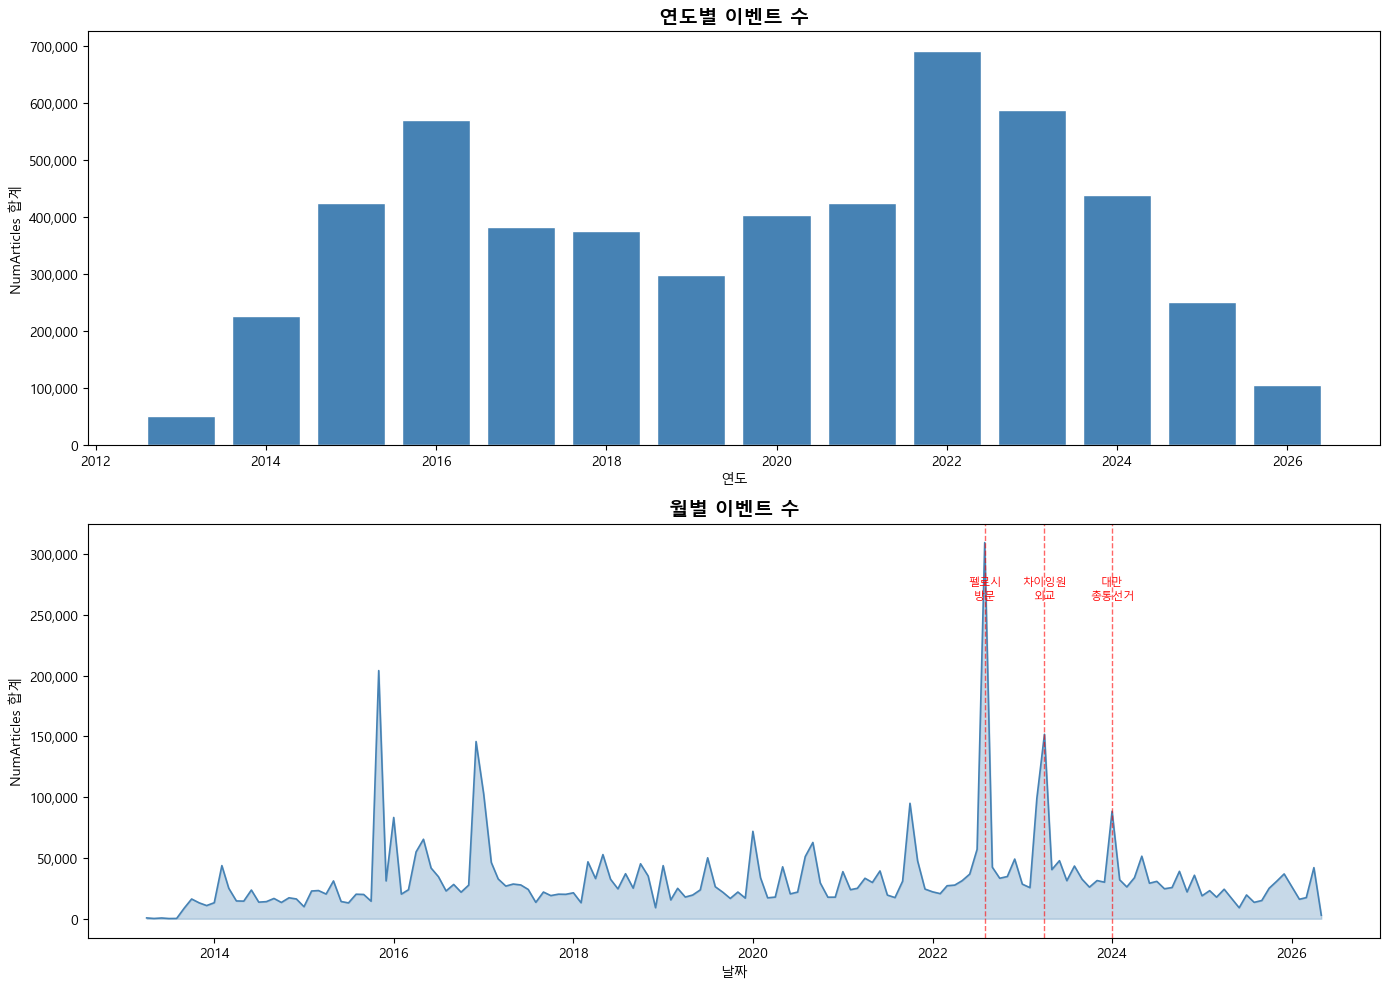

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── 연도별 이벤트 수 ──────────────────────────────
yearly = df.groupby('year')['NumArticles'].sum()

axes[0].bar(yearly.index, yearly.values, color='steelblue', edgecolor='white')
axes[0].set_title('연도별 이벤트 수', fontsize=14, fontweight='bold')
axes[0].set_xlabel('연도')
axes[0].set_ylabel('NumArticles 합계')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── 월별 이벤트 수 ────────────────────────────────
monthly = df.groupby(df['SQLDATE'].dt.to_period('M'))['NumArticles'].sum()
monthly.index = monthly.index.to_timestamp()

axes[1].plot(monthly.index, monthly.values, color='steelblue', linewidth=1.2)
axes[1].fill_between(monthly.index, monthly.values, alpha=0.3, color='steelblue')
axes[1].set_title('월별 이벤트 수', fontsize=14, fontweight='bold')
axes[1].set_xlabel('날짜')
axes[1].set_ylabel('NumArticles 합계')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 주요 사건 표시
events = {
    '2022-08': '펠로시\n방문',
    '2024-01': '대만\n총통선거',
    '2023-04': '차이잉원\n외교',
}
for date_str, label in events.items():
    x = pd.Timestamp(date_str)
    axes[1].axvline(x, color='red', linestyle='--', alpha=0.6, linewidth=1)
    axes[1].text(x, monthly.max() * 0.85, label, color='red', fontsize=8, ha='center')

plt.tight_layout()
plt.savefig('yearly_monthly_events.png', dpi=150, bbox_inches='tight')
plt.show()

#### 연도별 이벤트 수 분석 📊

눈에 띄는 패턴
2022~2023년이 확실한 피크

| 구간  | 연도 | 이벤트 수 | 해석 | 
|------|------|----------|-------| 
| 초기 | 2013 | 7,131 | GDELT 수집 초기라 데이터 적음 | 
| 성장기 | 2014~2016 | 점진적 증가 | 데이터 수집 안정화 | 
| 안정기 | 2017~2021 | 3~4만 유지 | 평상시 베이스라인 | 
| 피크 | 2022 | 53,629 | 펠로시 방문 + 中 군사훈련 | 
| 최고점 | 2023 | 57,482 | 차이잉원 외교 + 지속 긴장 | 
| 하락 | 2024 | 49,934 | 총통선거 후 다소 안정 | 
| 감소 | 2025 | 31,640 | 정상화 추세 | 
| 수집중 | 2026 | 10,604 | 아직 1년치 안 됨 (5월까지만) | 


중요한 관찰 2가지

① 2013년이 유독 적은 이유

GDELT 1.0이 2013년 4월부터 수집 시작이라 9개월치 데이터만 있어요. 분석할 때 2013년을 이상치로 오해하지 않도록 주의해야 한다.

② 2026년도 마찬가지

현재 5월까지만 있으니 연간 환산하면 약 25,000개 수준으로, 실제로는 2025년과 비슷하거나 더 낮을 수 있다.


이제 월 단위로 쪼개서 정확히 어느 달에 스파이크가 찍히는지 확인

In [16]:
# 월별 이벤트 수 + 평균 Tone
monthly = df.groupby(df['SQLDATE'].dt.to_period('M')).agg(
    event_count=('NumArticles', 'sum'),
    avg_tone=('AvgTone', 'mean')
).reset_index()

print(monthly.sort_values('event_count', ascending=False).head(20))

     SQLDATE  event_count  avg_tone
112  2022-08       309401 -2.619024
31   2015-11       204100 -0.763624
120  2023-04       151732 -1.868043
44   2016-12       145744 -1.457595
45   2017-01       102563 -1.420189
119  2023-03        98897 -1.276583
102  2021-10        94948 -2.435513
129  2024-01        88369 -1.235721
33   2016-01        83283 -0.910239
81   2020-01        71891 -1.910444
37   2016-05        65364 -1.333962
89   2020-09        62743 -2.230063
111  2022-07        57071 -2.237486
36   2016-04        54969 -4.349544
61   2018-05        52761 -0.804087
133  2024-05        51431 -1.976812
88   2020-08        51145 -1.906905
75   2019-07        50120 -1.866401
116  2022-12        49075 -2.368250
122  2023-06        47743 -1.721982


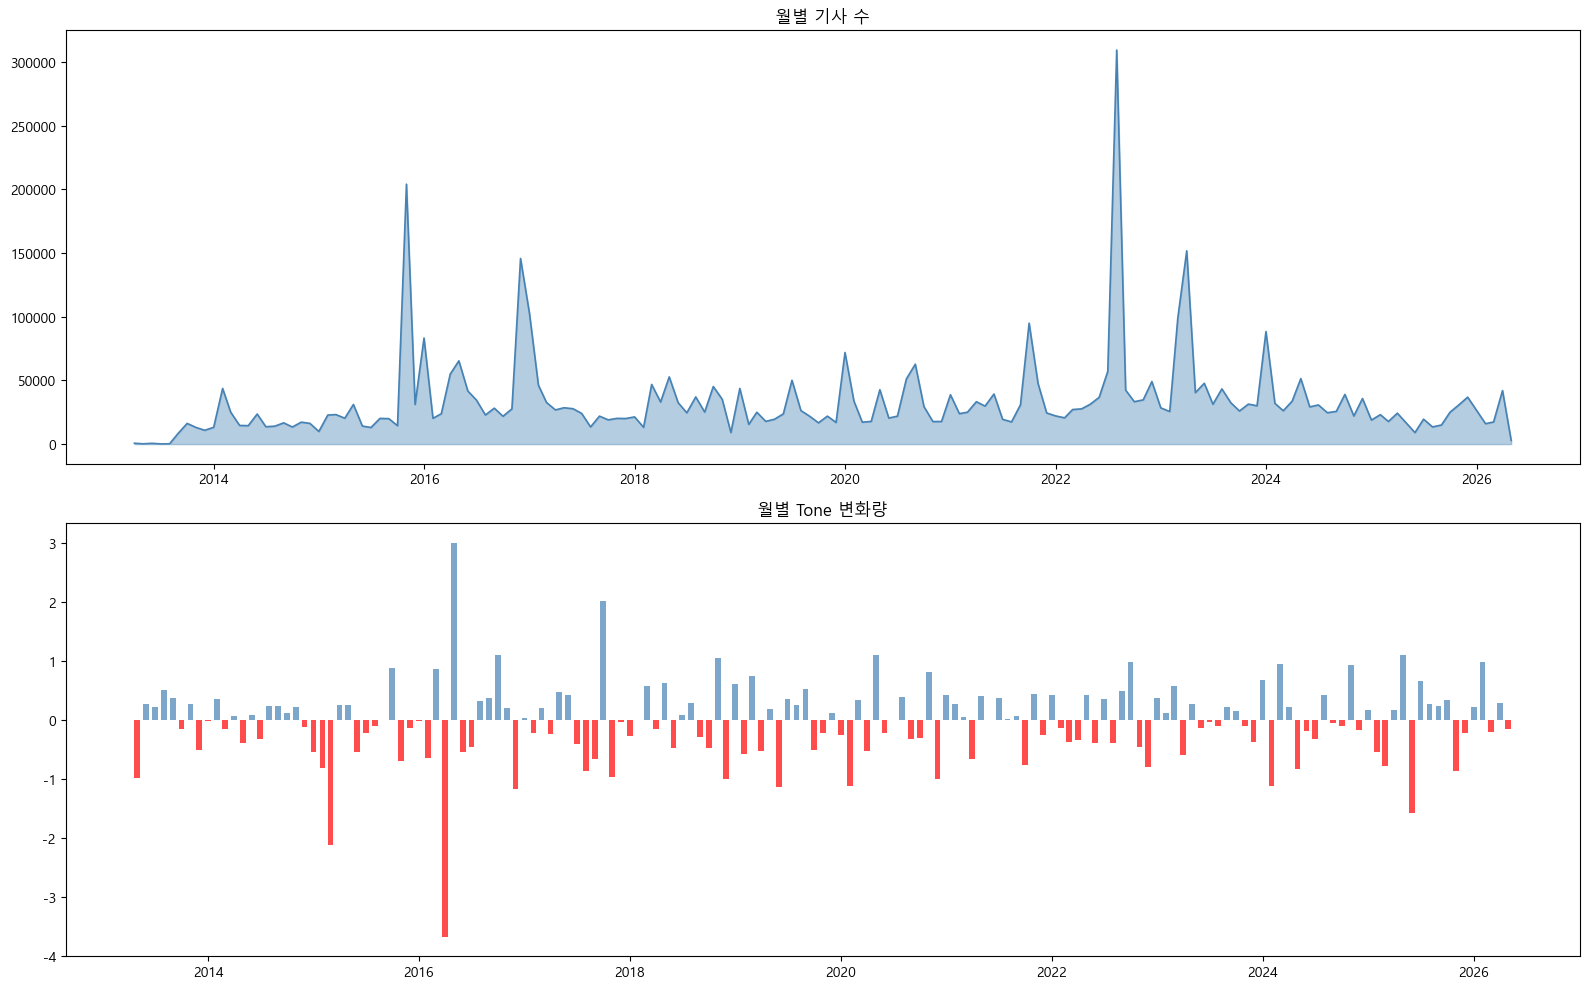

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# 데이터 준비
monthly = df.groupby(df['SQLDATE'].dt.to_period('M')).agg(
    event_count=('NumArticles', 'sum'),
    avg_tone=('AvgTone', 'mean')
).reset_index()
monthly['SQLDATE'] = monthly['SQLDATE'].dt.to_timestamp()
monthly['tone_delta'] = monthly['avg_tone'].diff()  # ← 이 줄 추가!

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].fill_between(monthly['SQLDATE'], monthly['event_count'], alpha=0.4, color='steelblue')
axes[0].plot(monthly['SQLDATE'], monthly['event_count'], color='steelblue', linewidth=1.2)
axes[0].set_title('월별 기사 수')

axes[1].bar(monthly['SQLDATE'], monthly['tone_delta'],
            color=monthly['tone_delta'].apply(lambda x: 'red' if x < 0 else 'steelblue'),
            width=20, alpha=0.7)
axes[1].set_title('월별 Tone 변화량')

plt.tight_layout()
plt.show()

#### 월별 Tone 변화량 읽는 법
이번 달 avg_tone - 지난 달 avg_tone = tone_delta

파란 막대 (+)  →  지난달보다 분위기가 좋아짐  (덜 적대적)
빨간 막대 (-)  →  지난달보다 분위기가 나빠짐  (더 적대적)

- 문제가 있음 특히 2번의 경우
    - ① 2016년 초 — 가장 큰 빨간 막대 (-3.7 근처)
        2016년 1월 대만 총통선거에서 차이잉원 당선 시점. 중국이 매우 강하게 반응했던 시기
    - ② 2022~2023년 — 기사 수는 역대 최고인데 Tone 변화량은 크지 않음
        기사가 폭발적으로 많아졌지만 변화량이 작다는 건 이미 분위기가 나쁜 상태가 지속됐다는 뜻. 갑자기 나빠진 게 아니라 나쁜 상태가 유지.

=>이미 분위기가 나쁜 상태가 지속됐다면 월변 변화량으로 부족할 수 있다. 즉, 나쁜 상태가 오래 지속되는 것을 놓친다.

#### 그래서 필요한 3가지 관점

관점 1. 절대 수준    →  지금 Tone이 전체 평균보다 얼마나 나쁜가?

관점 2. 변화량       →  갑자기 나빠졌는가?

관점 3. 지속 기간    →  나쁜 상태가 얼마나 오래 됐는가?



In [27]:
# 전체 평균과 표준편차 (기준선)
tone_mean = monthly['avg_tone'].mean()
tone_std  = monthly['avg_tone'].std()

# 관점 1: 절대 수준 — 전체 평균보다 1표준편차 이상 나쁜가?
monthly['is_low_tone'] = monthly['avg_tone'] < (tone_mean - tone_std)

# 관점 2: 변화량 — 전달보다 갑자기 나빠졌는가?
monthly['tone_delta'] = monthly['avg_tone'].diff()
monthly['is_sharp_drop'] = monthly['tone_delta'] < monthly['tone_delta'].quantile(0.1)

# 관점 3: 지속 기간 — 나쁜 상태가 몇 달째 지속되고 있는가?
monthly['bad_streak'] = (
    monthly['is_low_tone']
    .groupby((monthly['is_low_tone'] != monthly['is_low_tone'].shift()).cumsum())
    .cumcount() + 1
) * monthly['is_low_tone']

각각 어떤 상황을 잡는지
| 관점 | 잡아내는 상황 | 예시 | 
|------|--------------|-----|    
| 절대 수준 | 지금 분위기가 역사적으로 나쁜 구간 | 2022~2023 지속 긴장 | 
| 변화량 | 갑자기 분위기가 급격히 악화 | 펠로시 방문 직후 | 
| 지속 기간 | 나쁜 상태가 장기화 | 무역전쟁, 군사대치 장기화 | 

#### Priority Score에 반영하는 방법

In [28]:
# 세 가지를 합산해서 Tone 위험도 점수 만들기
monthly['tone_risk_score'] = (
    monthly['is_low_tone'].astype(int)      # 0 or 1
  + monthly['is_sharp_drop'].astype(int)    # 0 or 1
  + (monthly['bad_streak'] >= 3).astype(int) # 3달 이상 지속이면 1
)
# 최소 0점 ~ 최대 3점
# 3점 = 절대적으로 나쁘고 + 갑자기 더 나빠지고 + 오래 지속 → 즉시 위성 촬영 필요!

= tone_risk_score = 1  →  주의
- tone_risk_score = 2  →  경계
- tone_risk_score = 3  →  위성 촬영 즉시 필요 🛰️

### 1차적 필터링

전체 160개월 데이터 ->

이벤트 수 급증 OR Tone 위험도 높음(1차 필터) ->

후보 월 10~20개 추출 ->

실제 사건 검색 & 매칭  ← 사람이 직접 확인

In [22]:
# 튀는 구간 날짜 자동으로 뽑기
spike_months = monthly.nlargest(10, 'event_count')[['SQLDATE', 'event_count', 'avg_tone']]
print(spike_months)

       SQLDATE  event_count  avg_tone
112 2022-08-01       309401 -2.619024
31  2015-11-01       204100 -0.763624
120 2023-04-01       151732 -1.868043
44  2016-12-01       145744 -1.457595
45  2017-01-01       102563 -1.420189
119 2023-03-01        98897 -1.276583
102 2021-10-01        94948 -2.435513
129 2024-01-01        88369 -1.235721
33  2016-01-01        83283 -0.910239
81  2020-01-01        71891 -1.910444


In [29]:
count_mean = monthly['event_count'].mean()
count_std  = monthly['event_count'].std()

# 평균 + 1표준편차 이상 = 튀는 구간
monthly['is_spike_count'] = monthly['event_count'] > (count_mean + count_std)

In [30]:
monthly['is_spike_tone'] = monthly['tone_risk_score'] >= 2

In [31]:
# 둘 다 해당 → 강한 신호
monthly['spike_level'] = 'normal'
monthly.loc[monthly['is_spike_count'] | monthly['is_spike_tone'], 'spike_level'] = 'watch'    # 둘 중 하나
monthly.loc[monthly['is_spike_count'] & monthly['is_spike_tone'], 'spike_level'] = 'alert'    # 둘 다

# 결과 출력
result = monthly[monthly['spike_level'] != 'normal'][
    ['SQLDATE', 'event_count', 'avg_tone', 'tone_risk_score', 'spike_level']
].sort_values('event_count', ascending=False)

print(result)

       SQLDATE  event_count  avg_tone  tone_risk_score spike_level
112 2022-08-01       309401 -2.619024                0       watch
31  2015-11-01       204100 -0.763624                0       watch
120 2023-04-01       151732 -1.868043                0       watch
44  2016-12-01       145744 -1.457595                1       watch
45  2017-01-01       102563 -1.420189                0       watch
119 2023-03-01        98897 -1.276583                0       watch
102 2021-10-01        94948 -2.435513                0       watch
129 2024-01-01        88369 -1.235721                0       watch
33  2016-01-01        83283 -0.910239                0       watch
81  2020-01-01        71891 -1.910444                0       watch
36  2016-04-01        54969 -4.349544                2       watch
82  2020-02-01        33733 -3.024667                2       watch
84  2020-04-01        17810 -3.205124                2       watch
92  2020-12-01        17735 -2.696233                2       w

C:\Users\user\AppData\Local\Temp\ipykernel_492968\3043303116.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(yearly_data, labels=range(2013, 2027), patch_artist=True)


TypeError: float() argument must be a string or a real number, not 'NAType'

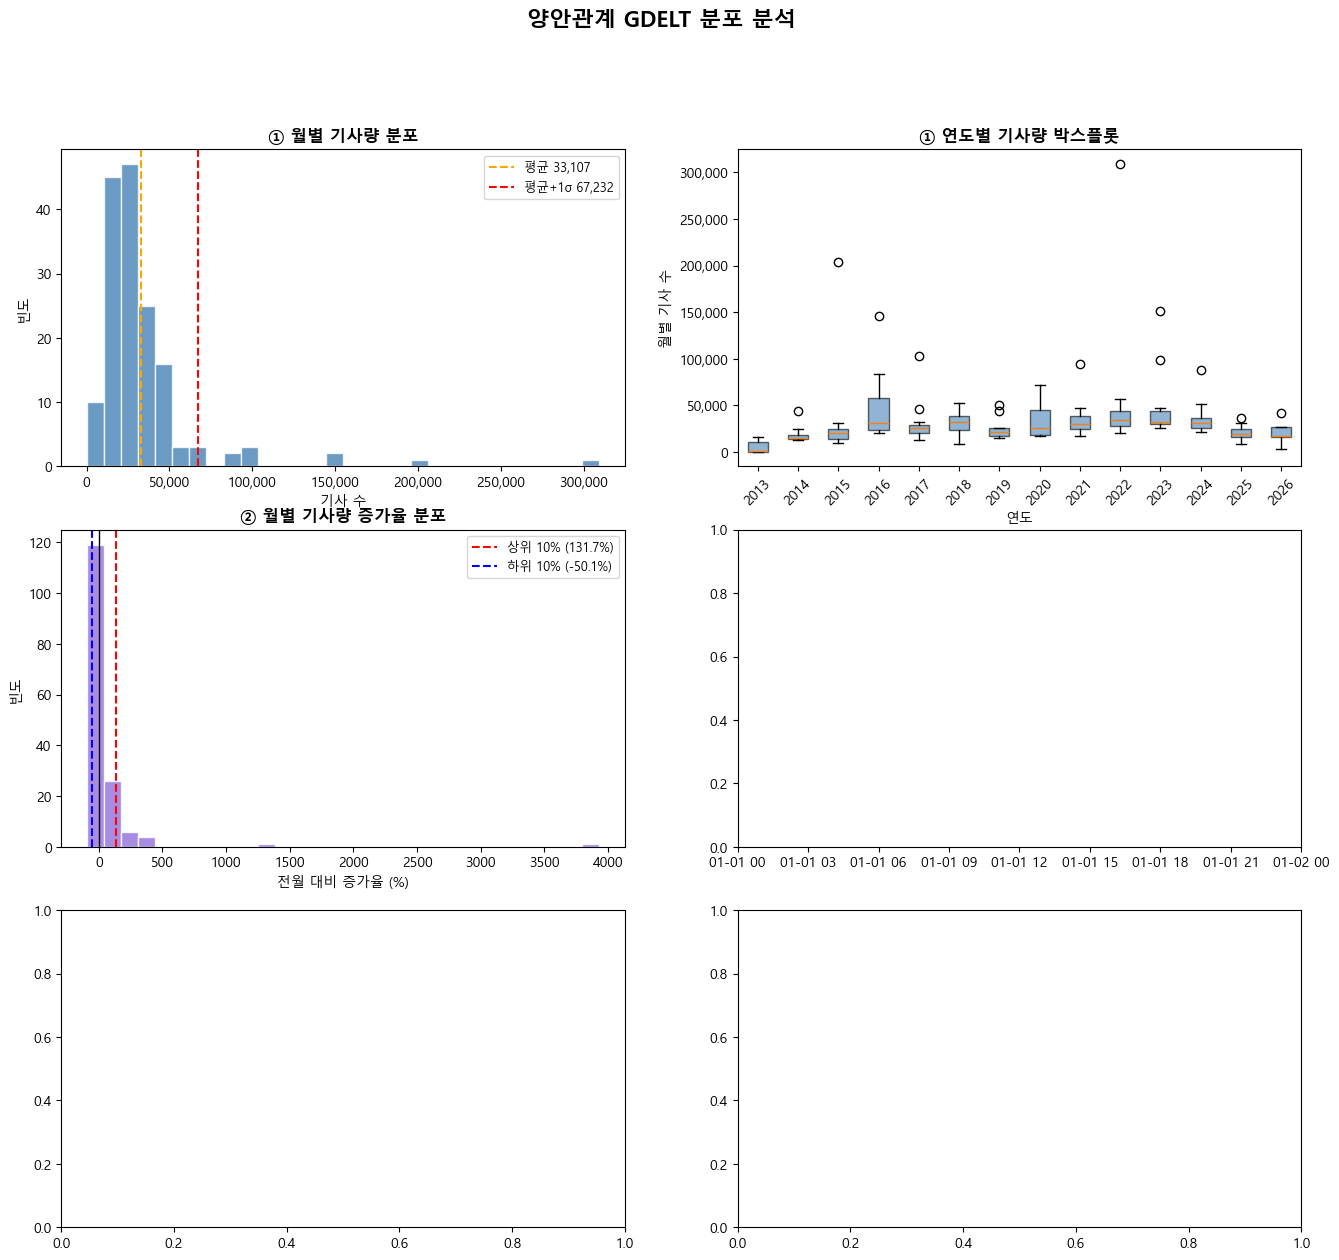

In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('양안관계 GDELT 분포 분석', fontsize=16, fontweight='bold', y=0.98)

# ── 데이터 준비 ──────────────────────────────────
monthly['count_pct_change'] = monthly['event_count'].pct_change() * 100  # 월별 증가율(%)

# ── ① 기사량 분포 (히스토그램) ───────────────────
ax = axes[0, 0]
ax.hist(monthly['event_count'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(monthly['event_count'].mean(), color='orange', linestyle='--', linewidth=1.5,
           label=f'평균 {monthly["event_count"].mean():,.0f}')
ax.axvline(monthly['event_count'].mean() + monthly['event_count'].std(),
           color='red', linestyle='--', linewidth=1.5,
           label=f'평균+1σ {monthly["event_count"].mean()+monthly["event_count"].std():,.0f}')
ax.set_title('① 월별 기사량 분포', fontsize=12, fontweight='bold')
ax.set_xlabel('기사 수')
ax.set_ylabel('빈도')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=9)

# ── ① 기사량 시계열 (박스플롯 대신 연도별) ────────
ax = axes[0, 1]
yearly_data = [monthly[monthly['SQLDATE'].dt.year == y]['event_count'].values
               for y in range(2013, 2027)]
bp = ax.boxplot(yearly_data, labels=range(2013, 2027), patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)
ax.set_title('① 연도별 기사량 박스플롯', fontsize=12, fontweight='bold')
ax.set_xlabel('연도')
ax.set_ylabel('월별 기사 수')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── ② 증가율 분포 (히스토그램) ───────────────────
ax = axes[1, 0]
clean_pct = monthly['count_pct_change'].dropna()
ax.hist(clean_pct, bins=30, color='mediumpurple', edgecolor='white', alpha=0.8)
ax.axvline(0, color='black', linewidth=1)
ax.axvline(clean_pct.quantile(0.9), color='red', linestyle='--', linewidth=1.5,
           label=f'상위 10% ({clean_pct.quantile(0.9):.1f}%)')
ax.axvline(clean_pct.quantile(0.1), color='blue', linestyle='--', linewidth=1.5,
           label=f'하위 10% ({clean_pct.quantile(0.1):.1f}%)')
ax.set_title('② 월별 기사량 증가율 분포', fontsize=12, fontweight='bold')
ax.set_xlabel('전월 대비 증가율 (%)')
ax.set_ylabel('빈도')
ax.legend(fontsize=9)

# ── ② 증가율 시계열 ───────────────────────────────
ax = axes[1, 1]
ax.bar(monthly['SQLDATE'], monthly['count_pct_change'],
       color=monthly['count_pct_change'].apply(lambda x: 'red' if x > clean_pct.quantile(0.9)
                                                else ('blue' if x < clean_pct.quantile(0.1)
                                                else 'gray')),
       width=20, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(clean_pct.quantile(0.9), color='red', linestyle='--', linewidth=1,
           label=f'상위 10% 기준선')
ax.axhline(clean_pct.quantile(0.1), color='blue', linestyle='--', linewidth=1,
           label=f'하위 10% 기준선')
ax.set_title('② 월별 기사량 증가율 시계열', fontsize=12, fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('증가율 (%)')
ax.legend(fontsize=9)

# ── ③ Goldstein Scale 분포 ───────────────────────
ax = axes[2, 0]
ax.hist(df['GoldsteinScale'], bins=40, color='coral', edgecolor='white', alpha=0.8)
ax.axvline(0, color='black', linewidth=1, label='중립선 (0)')
ax.axvline(df['GoldsteinScale'].mean(), color='orange', linestyle='--', linewidth=1.5,
           label=f'평균 {df["GoldsteinScale"].mean():.2f}')
ax.set_title('③ Goldstein Scale 분포 (전체 이벤트)', fontsize=12, fontweight='bold')
ax.set_xlabel('Goldstein Scale (-10 ~ +10)')
ax.set_ylabel('빈도')
ax.legend(fontsize=9)

# ── ③ Goldstein Scale 월별 평균 시계열 ───────────
ax = axes[2, 1]
monthly_gold = df.groupby(df['SQLDATE'].dt.to_period('M'))['GoldsteinScale'].mean()
monthly_gold.index = monthly_gold.index.to_timestamp()

ax.plot(monthly_gold.index, monthly_gold.values, color='coral', linewidth=1.2)
ax.fill_between(monthly_gold.index, monthly_gold.values,
                where=(monthly_gold.values < 0), color='red', alpha=0.3, label='갈등 우세')
ax.fill_between(monthly_gold.index, monthly_gold.values,
                where=(monthly_gold.values >= 0), color='green', alpha=0.3, label='협력 우세')
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(monthly_gold.mean(), color='orange', linestyle='--', linewidth=1,
           label=f'전체 평균 ({monthly_gold.mean():.2f})')
ax.set_title('③ 월별 Goldstein Scale 평균 시계열', fontsize=12, fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('Goldstein Scale')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('distribution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Goldstein과 Tone이 실제로 다른 정보를 담고 있는지 숫자로 증명

확인할 것들

① 상관관계 — 둘이 얼마나 겹치는가

상관계수 -1.0 ~ +1.0

0에 가까울수록  →  서로 다른 정보를 담고 있음 → 둘 다 써야 함

1에 가까울수록  →  거의 같은 정보 → 하나만 써도 됨

② 분포 차이 — 각각 어떻게 생겼는가

③ 실제 스파이크 구간에서 둘의 움직임 — 같이 움직이는지 따로 움직이는지



In [38]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

# ── 데이터 준비 ──────────────────────────────────
# CAMEO 필터링 적용
cameo_filter = df['EventRootCode'].isin(['15', '19', '20']) 
df_filtered = df[cameo_filter].copy()

print(f"전체 데이터:        {len(df):,}개")
print(f"CAMEO 필터링 후:    {len(df_filtered):,}개")
print(f"필터링 비율:        {len(df_filtered)/len(df)*100:.1f}%")

전체 데이터:        493,109개
CAMEO 필터링 후:    30,886개
필터링 비율:        6.3%


In [39]:
# ── ① 상관관계 분석 ──────────────────────────────
corr_전체, p_전체 = stats.pearsonr(
    df['GoldsteinScale'], df['AvgTone']
)
corr_필터, p_필터 = stats.pearsonr(
    df_filtered['GoldsteinScale'], df_filtered['AvgTone']
)

print("\n=== 상관관계 분석 ===")
print(f"[전체]         상관계수: {corr_전체:.3f}  (p-value: {p_전체:.4f})")
print(f"[CAMEO 필터후] 상관계수: {corr_필터:.3f}  (p-value: {p_필터:.4f})")


=== 상관관계 분석 ===
[전체]         상관계수: nan  (p-value: nan)
[CAMEO 필터후] 상관계수: 0.026  (p-value: 0.0000)


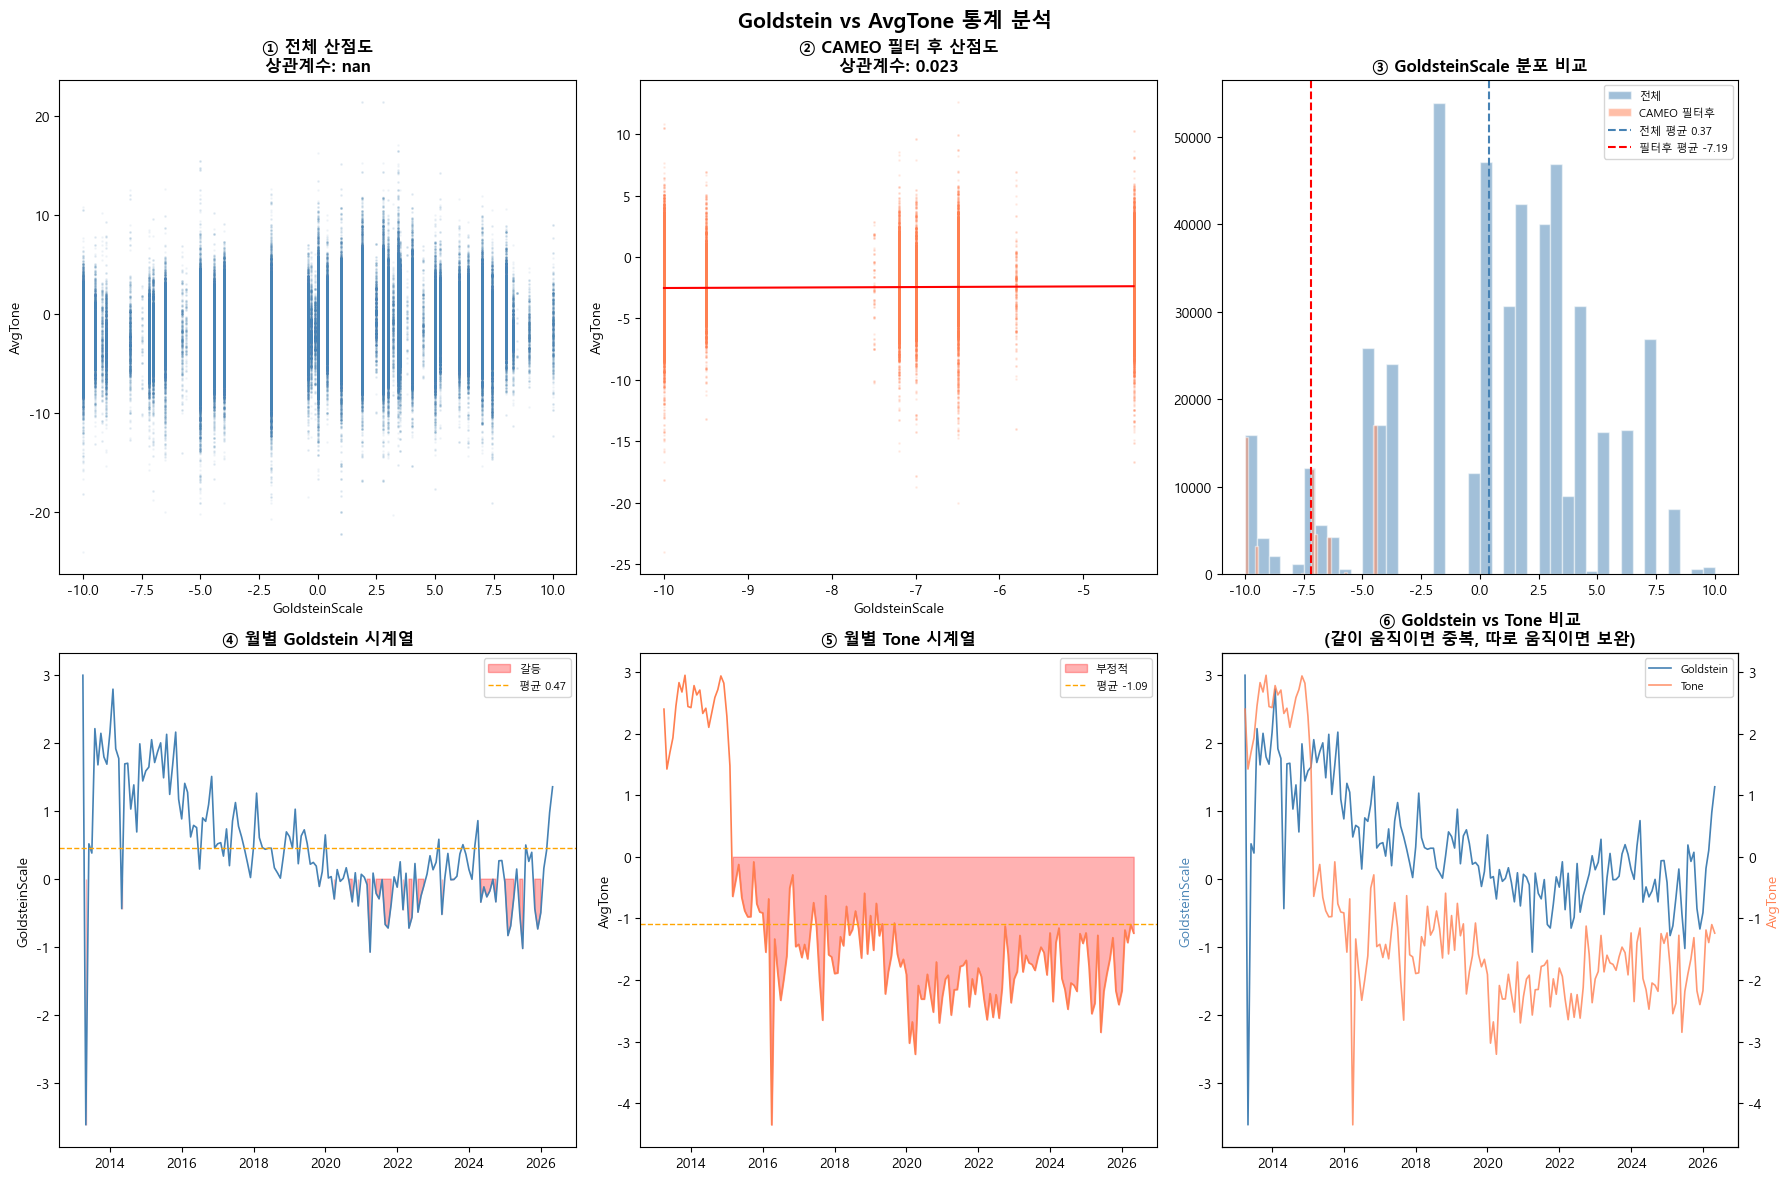

In [37]:
from scipy import stats as sp_stats

# ── ② 시각화 ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Goldstein vs AvgTone 통계 분석', fontsize=15, fontweight='bold')

# 전체 데이터 산점도
ax = axes[0, 0]
ax.scatter(df['GoldsteinScale'], df['AvgTone'],
           alpha=0.05, s=1, color='steelblue')

slope, intercept, r, p, se = sp_stats.linregress(
    df['GoldsteinScale'], df['AvgTone']
)
x_line = np.linspace(df['GoldsteinScale'].min(), df['GoldsteinScale'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=1.5)
ax.set_xlabel('GoldsteinScale')
ax.set_ylabel('AvgTone')
ax.set_title(f'① 전체 산점도\n상관계수: {corr_전체:.3f}', fontweight='bold')

# CAMEO 필터 후 산점도
ax = axes[0, 1]
ax.scatter(df_filtered['GoldsteinScale'], df_filtered['AvgTone'],
           alpha=0.1, s=1, color='coral')
ax.set_xlabel('GoldsteinScale')
ax.set_ylabel('AvgTone')
ax.set_title(f'② CAMEO 필터 후 산점도\n상관계수: {corr_필터:.3f}', fontweight='bold')

m2, b2 = np.polyfit(df_filtered['GoldsteinScale'], df_filtered['AvgTone'], 1)
x_line2 = np.linspace(df_filtered['GoldsteinScale'].min(),
                       df_filtered['GoldsteinScale'].max(), 100)
ax.plot(x_line2, m2 * x_line2 + b2, color='red', linewidth=1.5)

# GoldsteinScale 분포
ax = axes[0, 2]
ax.hist(df['GoldsteinScale'], bins=40, color='steelblue',
        alpha=0.5, label='전체', edgecolor='white')
ax.hist(df_filtered['GoldsteinScale'], bins=40, color='coral',
        alpha=0.5, label='CAMEO 필터후', edgecolor='white')
ax.axvline(df['GoldsteinScale'].mean(), color='steelblue',
           linestyle='--', linewidth=1.5,
           label=f'전체 평균 {df["GoldsteinScale"].mean():.2f}')
ax.axvline(df_filtered['GoldsteinScale'].mean(), color='red',
           linestyle='--', linewidth=1.5,
           label=f'필터후 평균 {df_filtered["GoldsteinScale"].mean():.2f}')
ax.set_title('③ GoldsteinScale 분포 비교', fontweight='bold')
ax.legend(fontsize=8)

# 월별 시계열 비교
monthly_stat = df.groupby(df['SQLDATE'].dt.to_period('M')).agg(
    goldstein=('GoldsteinScale', 'mean'),
    tone=('AvgTone', 'mean')
).reset_index()
monthly_stat['SQLDATE'] = monthly_stat['SQLDATE'].dt.to_timestamp()

# Goldstein 시계열
ax = axes[1, 0]
ax.plot(monthly_stat['SQLDATE'], monthly_stat['goldstein'],
        color='steelblue', linewidth=1.2)
ax.fill_between(monthly_stat['SQLDATE'], monthly_stat['goldstein'],
                where=(monthly_stat['goldstein'] < 0),
                color='red', alpha=0.3, label='갈등')
ax.axhline(monthly_stat['goldstein'].mean(), color='orange',
           linestyle='--', linewidth=1,
           label=f'평균 {monthly_stat["goldstein"].mean():.2f}')
ax.set_title('④ 월별 Goldstein 시계열', fontweight='bold')
ax.set_ylabel('GoldsteinScale')
ax.legend(fontsize=8)

# Tone 시계열
ax = axes[1, 1]
ax.plot(monthly_stat['SQLDATE'], monthly_stat['tone'],
        color='coral', linewidth=1.2)
ax.fill_between(monthly_stat['SQLDATE'], monthly_stat['tone'],
                where=(monthly_stat['tone'] < 0),
                color='red', alpha=0.3, label='부정적')
ax.axhline(monthly_stat['tone'].mean(), color='orange',
           linestyle='--', linewidth=1,
           label=f'평균 {monthly_stat["tone"].mean():.2f}')
ax.set_title('⑤ 월별 Tone 시계열', fontweight='bold')
ax.set_ylabel('AvgTone')
ax.legend(fontsize=8)

# 둘을 겹쳐서 비교
ax = axes[1, 2]
ax2_twin = ax.twinx()  # 축 두 개 (단위가 다르니까)

ax.plot(monthly_stat['SQLDATE'], monthly_stat['goldstein'],
        color='steelblue', linewidth=1.2, label='Goldstein')
ax2_twin.plot(monthly_stat['SQLDATE'], monthly_stat['tone'],
              color='coral', linewidth=1.2, label='Tone', alpha=0.8)

ax.set_ylabel('GoldsteinScale', color='steelblue')
ax2_twin.set_ylabel('AvgTone', color='coral')
ax.set_title('⑥ Goldstein vs Tone 비교\n(같이 움직이면 중복, 따로 움직이면 보완)', fontweight='bold')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.savefig('goldstein_tone_stats.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
import pandas as pd

# 기본 파악
print("shape:", df.shape)
print("\n결측값 비율(%)")
print((df.isnull().mean() * 100).round(2))

# 날짜 변환
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d')
print("\n날짜 범위:", df['SQLDATE'].min(), "~", df['SQLDATE'].max())

# 연도별 분포
df['year'] = df['SQLDATE'].dt.year
print("\n연도별 이벤트 수")
print(df['year'].value_counts().sort_index())

shape: (493109, 20)

결측값 비율(%)
SQLDATE                  0.00
IsRootEvent              0.00
Actor1CountryCode        0.00
Actor2CountryCode        0.00
EventCode                0.00
EventBaseCode            0.00
EventRootCode            0.00
GoldsteinScale           0.00
QuadClass                0.00
NumMentions              0.00
NumArticles              0.00
NumSources               0.00
AvgTone                  0.00
ActionGeo_Type           0.00
ActionGeo_Lat            0.01
ActionGeo_Long           0.01
ActionGeo_FullName       0.03
ActionGeo_CountryCode    0.01
SOURCEURL                0.00
year                     0.00
dtype: float64

날짜 범위: 2013-04-01 00:00:00 ~ 2026-05-04 00:00:00

연도별 이벤트 수
year
2013     7131
2014    28373
2015    35660
2016    47209
2017    31799
2018    30875
2019    32101
2020    37586
2021    39086
2022    53629
2023    57482
2024    49934
2025    31640
2026    10604
Name: count, dtype: int64
